# 0825_kimjaehak_012_type2_undersampling_robustness

`0825_kimjaehak_009_partial_rebalancing`에서 선택된 **inspection_type=2 + 1:4 Random Undersampling**의 추가 재현성을 검증합니다.

실험은 사전에 고정한 두 단계를 순서대로 수행합니다.

1. 009와 동일한 60/20/20 split에서 sampler seed만 바꿔 결과 자체를 재현합니다.
2. 설정을 바꾸지 않고 expanding walk-forward에서 여러 기간으로 일반화되는지 검증합니다.

새로운 비율 탐색, 다른 리샘플링 기법 탐색, threshold 최적화는 수행하지 않습니다. XGBoost seed는 42로 고정하고 sampler seed만 42~51로 바꿉니다.

## 1. 설정과 라이브러리

PR-AUC를 주지표로 사용합니다. 리샘플링으로 raw probability scale이 변할 수 있으므로 threshold 0.5의 Precision, Recall, F1과 confusion matrix는 보조 지표로만 해석합니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_012_type2_undersampling_robustness"
RANDOM_STATE = 42
SAMPLER_SEEDS = list(range(42, 52))
INSPECTION_TYPE = 2
SAMPLING_STRATEGY = 0.25
DECISION_THRESHOLD = 0.5
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
ALL_WINDOWS = [f"W{number:02d}" for number in range(1, 11)]

assert DATA_PATH.exists(), DATA_PATH.resolve()
assert MAPPING_PATH.exists(), MAPPING_PATH.resolve()
assert len(SAMPLER_SEEDS) == len(set(SAMPLER_SEEDS)) == 10
print("experiment:", EXPERIMENT_ID)
print("fixed intervention:", f"type={INSPECTION_TYPE}, RandomUnderSampler={SAMPLING_STRATEGY}")
print("sampler seeds:", SAMPLER_SEEDS)

Matplotlib is building the font cache; this may take a moment.


experiment: 0825_kimjaehak_012_type2_undersampling_robustness
fixed intervention: type=2, RandomUnderSampler=0.25
sampler seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## 2. 데이터 준비와 두 시간 분할

- 중복 제거와 60/20/20 경계는 006·009와 동일합니다.
- 10개 window는 timestamp 그룹을 분리하지 않는 누적 행 수 약 10% 단위입니다.
- 모든 경계는 전체 데이터에서 계산한 뒤 inspection_type=2만 추출합니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side="left"))
    return timestamp_group_sizes.index[position]

train_end_time = boundary_time(0.60)
validation_end_time = boundary_time(0.80)
split_masks = {
    "train": clean_df[TIME_COLUMN] <= train_end_time,
    "validation": (
        (clean_df[TIME_COLUMN] > train_end_time)
        & (clean_df[TIME_COLUMN] <= validation_end_time)
    ),
    "test": clean_df[TIME_COLUMN] > validation_end_time,
}

window_end_times = pd.DatetimeIndex(
    [boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)]
)
window_number = np.searchsorted(
    window_end_times.astype("int64").to_numpy(),
    clean_df[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
clean_df["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in window_number],
    categories=ALL_WINDOWS,
    ordered=True,
)

with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)
meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
feature_columns = meta_columns + feature_mapping[str(INSPECTION_TYPE)]
assert len(feature_columns) == len(set(feature_columns))
assert not (set(feature_columns) - set(clean_df.columns))

type_df = clean_df.loc[clean_df[TYPE_COLUMN] == INSPECTION_TYPE].copy()
fixed_split_dfs = {
    split_name: type_df.loc[mask].copy()
    for split_name, mask in split_masks.items()
}

data_summary = pd.DataFrame([
    {
        "scope": "all_after_dedup",
        "rows": len(clean_df),
        "positives": int(clean_df[TARGET].sum()),
        "positive_rate_pct": clean_df[TARGET].mean() * 100,
        "start_time": clean_df[TIME_COLUMN].min(),
        "end_time": clean_df[TIME_COLUMN].max(),
    },
    *[
        {
            "scope": f"type2_{split_name}",
            "rows": len(frame),
            "positives": int(frame[TARGET].sum()),
            "positive_rate_pct": frame[TARGET].mean() * 100,
            "start_time": frame[TIME_COLUMN].min(),
            "end_time": frame[TIME_COLUMN].max(),
        }
        for split_name, frame in fixed_split_dfs.items()
    ],
]).set_index("scope")

window_summary = type_df.groupby("window", observed=False).agg(
    rows=(TARGET, "size"),
    positives=(TARGET, "sum"),
    positive_rate=(TARGET, "mean"),
)
window_summary["positive_rate_pct"] = window_summary["positive_rate"] * 100

assert len(clean_df) == 391_992
assert sum(split_masks.values()).eq(1).all()
assert clean_df.groupby(TIME_COLUMN)["window"].nunique().max() == 1
display(data_summary)
display(window_summary)

,rows,positives,positive_rate_pct,start_time,end_time
scope,,,,,
all_after_dedup,391992,4436,1.131656,1970-06-23 03:58:55+00:00,1970-11-02 14:21:28+00:00
type2_train,74910,579,0.772928,1970-06-23 04:01:30+00:00,1970-09-28 05:48:26+00:00
type2_validation,15897,32,0.201296,1970-09-28 05:49:10+00:00,1970-10-13 13:13:56+00:00
type2_test,19153,703,3.670443,1970-10-13 13:19:37+00:00,1970-11-02 14:21:28+00:00


,rows,positives,positive_rate,positive_rate_pct
window,,,,
W01,9469,9,0.000950,0.095047
W02,10225,281,0.027482,2.748166
W03,15843,118,0.007448,0.744808
W04,17056,92,0.005394,0.539400
W05,15209,48,0.003156,0.315603
W06,7108,31,0.004361,0.436128
W07,11359,7,0.000616,0.061625
W08,4538,25,0.005509,0.550903
W09,10635,407,0.038270,3.826986


## 3. 공통 학습과 평가 함수

XGBoost 설정은 006·009와 동일합니다. 각 반복에서 Train에만 undersampling을 적용하며 평가 데이터의 행과 클래스 분포는 바꾸지 않습니다.

In [3]:
def build_model():
    return XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )


def safe_roc_auc(y_true, probabilities):
    return roc_auc_score(y_true, probabilities) if len(np.unique(y_true)) > 1 else np.nan


def evaluate_probabilities(y_true, probabilities, threshold=DECISION_THRESHOLD):
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    predictions = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def fit_and_evaluate(train_df, evaluation_frames, variant, sampler_seed):
    X_train = train_df[feature_columns]
    y_train = train_df[TARGET].astype("int8")

    if variant == "baseline":
        X_fit, y_fit = X_train, y_train
    elif variant == "undersample_0.25":
        original_ratio = y_train.sum() / (len(y_train) - y_train.sum())
        assert SAMPLING_STRATEGY > original_ratio
        sampler = RandomUnderSampler(
            sampling_strategy=SAMPLING_STRATEGY,
            random_state=sampler_seed,
        )
        X_fit, y_fit = sampler.fit_resample(X_train, y_train)
    else:
        raise ValueError(variant)

    model = build_model()
    model.fit(X_fit, y_fit, verbose=False)
    evaluations = {}
    for frame_name, evaluation_df in evaluation_frames.items():
        probabilities = model.predict_proba(evaluation_df[feature_columns])[:, 1]
        evaluations[frame_name] = evaluate_probabilities(
            evaluation_df[TARGET].astype("int8"), probabilities
        )
    return {
        "evaluations": evaluations,
        "train_rows_original": len(y_train),
        "train_rows_fitted": len(y_fit),
        "train_positives": int(y_train.sum()),
    }

## 4. 1단계 — 009 동일 split 재현

Train은 그대로 고정합니다. Baseline은 결정론적이므로 한 번만 학습하고, 1:4 undersampling만 sampler seed 42~51로 반복합니다. Validation과 Test를 모두 예측하되 새 후보 선택에는 사용하지 않습니다. 이미 009에서 확인한 Test를 다시 사용하므로 결과는 새로운 독립 Test가 아니라 회고적 재현성 점검입니다.

In [4]:
stage1_baseline = fit_and_evaluate(
    fixed_split_dfs["train"],
    {
        "validation": fixed_split_dfs["validation"],
        "test": fixed_split_dfs["test"],
    },
    variant="baseline",
    sampler_seed=RANDOM_STATE,
)

stage1_rows = []
for sampler_seed in SAMPLER_SEEDS:
    result = fit_and_evaluate(
        fixed_split_dfs["train"],
        {
            "validation": fixed_split_dfs["validation"],
            "test": fixed_split_dfs["test"],
        },
        variant="undersample_0.25",
        sampler_seed=sampler_seed,
    )
    row = {
        "sampler_seed": sampler_seed,
        "train_rows_original": result["train_rows_original"],
        "train_rows_fitted": result["train_rows_fitted"],
    }
    for split_name in ["validation", "test"]:
        baseline_metrics = stage1_baseline["evaluations"][split_name]
        undersampled_metrics = result["evaluations"][split_name]
        for metric_name, metric_value in undersampled_metrics.items():
            row[f"{split_name}_{metric_name}"] = metric_value
        row[f"{split_name}_baseline_pr_auc"] = baseline_metrics["pr_auc"]
        row[f"{split_name}_delta_pr_auc"] = (
            undersampled_metrics["pr_auc"] - baseline_metrics["pr_auc"]
        )
    stage1_rows.append(row)

stage1_seed_results = pd.DataFrame(stage1_rows)
seed42_row = stage1_seed_results.loc[stage1_seed_results["sampler_seed"] == 42].iloc[0]
assert abs(stage1_baseline["evaluations"]["test"]["pr_auc"] - 0.356827) < 1e-5
assert abs(seed42_row["test_pr_auc"] - 0.561603) < 1e-5
display(stage1_seed_results)

,sampler_seed,train_rows_original,train_rows_fitted,validation_pr_auc,validation_roc_auc,validation_precision,validation_recall,validation_f1,validation_tn,validation_fp,...,test_roc_auc,test_precision,test_recall,test_f1,test_tn,test_fp,test_fn,test_tp,test_baseline_pr_auc,test_delta_pr_auc
0,42,74910,2895,0.313442,0.895669,0.079295,0.56250,0.138996,15656,209,...,0.911834,0.388018,0.598862,0.470917,17786,664,282,421,0.356827,0.204776
1,43,74910,2895,0.040080,0.878861,0.049861,0.56250,0.091603,15522,343,...,0.901531,0.317919,0.625889,0.421658,17506,944,263,440,0.356827,0.142947
2,44,74910,2895,0.177806,0.857253,0.074890,0.53125,0.131274,15655,210,...,0.908091,0.462924,0.621622,0.530662,17943,507,266,437,0.356827,0.198920
3,45,74910,2895,0.145228,0.909111,0.055172,0.50000,0.099379,15591,274,...,0.891398,0.491289,0.601707,0.540921,18012,438,280,423,0.356827,0.251799
4,46,74910,2895,0.089302,0.927032,0.043011,0.50000,0.079208,15509,356,...,0.896276,0.360589,0.627312,0.457944,17668,782,262,441,0.356827,0.232031
5,47,74910,2895,0.331072,0.862413,0.057627,0.53125,0.103976,15587,278,...,0.895832,0.354916,0.631579,0.454452,17643,807,259,444,0.356827,0.217593
6,48,74910,2895,0.254831,0.905507,0.045113,0.56250,0.083527,15484,381,...,0.900662,0.335413,0.611664,0.433249,17598,852,273,430,0.356827,0.241462
7,49,74910,2895,0.372506,0.907276,0.063830,0.56250,0.114650,15601,264,...,0.908143,0.491601,0.624467,0.550125,17996,454,264,439,0.356827,0.142467
8,50,74910,2895,0.151227,0.887405,0.051988,0.53125,0.094708,15555,310,...,0.896728,0.351794,0.641536,0.454408,17619,831,252,451,0.356827,0.209565
9,51,74910,2895,0.275993,0.892424,0.066929,0.53125,0.118881,15628,237,...,0.911820,0.524492,0.624467,0.570130,18052,398,264,439,0.356827,0.181910


In [5]:
stage1_summary_rows = []
for split_name in ["validation", "test"]:
    values = stage1_seed_results[f"{split_name}_pr_auc"]
    deltas = stage1_seed_results[f"{split_name}_delta_pr_auc"]
    stage1_summary_rows.append({
        "split": split_name,
        "baseline_pr_auc": stage1_baseline["evaluations"][split_name]["pr_auc"],
        "undersampled_pr_auc_mean": values.mean(),
        "undersampled_pr_auc_std": values.std(ddof=1),
        "undersampled_pr_auc_min": values.min(),
        "undersampled_pr_auc_max": values.max(),
        "median_delta_pr_auc": deltas.median(),
        "win_rate_vs_baseline": (deltas > 0).mean(),
    })
stage1_summary = pd.DataFrame(stage1_summary_rows).set_index("split")

stage1_strong = (
    (stage1_summary["median_delta_pr_auc"] > 0).all()
    and (stage1_summary["win_rate_vs_baseline"] >= 0.80).all()
)
stage1_partial = (
    (stage1_summary["median_delta_pr_auc"] > 0).all()
    and (stage1_summary["win_rate_vs_baseline"] >= 0.60).all()
)
stage1_judgement = "strong" if stage1_strong else "partial" if stage1_partial else "failed"

display(stage1_summary)
display(pd.DataFrame([
    {
        "variant": "baseline",
        **stage1_baseline["evaluations"]["test"],
    },
    {
        "variant": "undersample_seed42",
        **stage1_seed_results.loc[
            stage1_seed_results["sampler_seed"] == 42,
            [f"test_{name}" for name in ["pr_auc", "roc_auc", "precision", "recall", "f1", "tn", "fp", "fn", "tp"]],
        ].rename(columns=lambda name: name.removeprefix("test_")).iloc[0].to_dict(),
    },
]).set_index("variant"))
print("stage1 judgement:", stage1_judgement)

,baseline_pr_auc,undersampled_pr_auc_mean,undersampled_pr_auc_std,undersampled_pr_auc_min,undersampled_pr_auc_max,median_delta_pr_auc,win_rate_vs_baseline
split,,,,,,,
validation,0.050334,0.215149,0.110551,0.040080,0.372506,0.165984,0.9
test,0.356827,0.559174,0.037551,0.499294,0.608625,0.207170,1.0


,pr_auc,roc_auc,precision,recall,f1,tn,fp,fn,tp
variant,,,,,,,,,
baseline,0.356827,0.887697,0.513742,0.345661,0.413265,18220.0,230.0,460.0,243.0
undersample_seed42,0.561603,0.911834,0.388018,0.598862,0.470917,17786.0,664.0,282.0,421.0


stage1 judgement: strong


## 5. 2단계 — Expanding walk-forward 기간 강건성

1단계와 관계없이 사전에 고정한 6개 Fold를 모두 실행합니다.

| Fold | 학습 | 평가 |
|---|---|---|
| 1 | W01~W04 | W05 |
| 2 | W01~W05 | W06 |
| 3 | W01~W06 | W07 |
| 4 | W01~W07 | W08 |
| 5 | W01~W08 | W09 |
| 6 | W01~W09 | W10 |

평가된 window가 다음 Fold의 학습에 들어가는 expanding 구조지만, 각 Fold에서는 항상 평가 시점보다 과거 데이터만 학습에 사용합니다.

In [6]:
walk_forward_rows = []

for evaluation_position in range(4, 10):
    train_windows = ALL_WINDOWS[:evaluation_position]
    evaluation_window = ALL_WINDOWS[evaluation_position]
    train_df = type_df.loc[type_df["window"].isin(train_windows)]
    evaluation_df = type_df.loc[type_df["window"] == evaluation_window]
    assert train_df[TIME_COLUMN].max() < evaluation_df[TIME_COLUMN].min()

    baseline_result = fit_and_evaluate(
        train_df,
        {"evaluation": evaluation_df},
        variant="baseline",
        sampler_seed=RANDOM_STATE,
    )
    baseline_metrics = baseline_result["evaluations"]["evaluation"]

    for sampler_seed in SAMPLER_SEEDS:
        undersampled_result = fit_and_evaluate(
            train_df,
            {"evaluation": evaluation_df},
            variant="undersample_0.25",
            sampler_seed=sampler_seed,
        )
        metrics = undersampled_result["evaluations"]["evaluation"]
        walk_forward_rows.append({
            "evaluation_window": evaluation_window,
            "training_windows": "~".join(train_windows),
            "sampler_seed": sampler_seed,
            "evaluation_rows": len(evaluation_df),
            "evaluation_positives": int(evaluation_df[TARGET].sum()),
            "train_rows_original": undersampled_result["train_rows_original"],
            "train_rows_fitted": undersampled_result["train_rows_fitted"],
            **{f"baseline_{name}": value for name, value in baseline_metrics.items()},
            **{f"undersampled_{name}": value for name, value in metrics.items()},
            "delta_pr_auc": metrics["pr_auc"] - baseline_metrics["pr_auc"],
            "delta_recall": metrics["recall"] - baseline_metrics["recall"],
            "delta_tn": metrics["tn"] - baseline_metrics["tn"],
            "delta_fn": metrics["fn"] - baseline_metrics["fn"],
        })

walk_forward_seed_results = pd.DataFrame(walk_forward_rows)
assert len(walk_forward_seed_results) == 60
display(walk_forward_seed_results[[
    "evaluation_window", "training_windows", "sampler_seed",
    "baseline_pr_auc", "undersampled_pr_auc", "delta_pr_auc",
    "delta_recall", "delta_tn", "delta_fn",
]])

,evaluation_window,training_windows,sampler_seed,baseline_pr_auc,undersampled_pr_auc,delta_pr_auc,delta_recall,delta_tn,delta_fn
0,W05,W01~W02~W03~W04,42,0.483620,0.208966,-0.274654,0.125000,-1688,-6
1,W05,W01~W02~W03~W04,43,0.483620,0.237013,-0.246607,0.083333,-1569,-4
2,W05,W01~W02~W03~W04,44,0.483620,0.272491,-0.211129,0.083333,-606,-4
3,W05,W01~W02~W03~W04,45,0.483620,0.262464,-0.221156,0.083333,-858,-4
4,W05,W01~W02~W03~W04,46,0.483620,0.327820,-0.155800,0.104167,-558,-5
5,W05,W01~W02~W03~W04,47,0.483620,0.222514,-0.261106,0.062500,-907,-3
6,W05,W01~W02~W03~W04,48,0.483620,0.307021,-0.176600,0.041667,-1597,-2
7,W05,W01~W02~W03~W04,49,0.483620,0.322452,-0.161168,0.083333,-1278,-4
8,W05,W01~W02~W03~W04,50,0.483620,0.244941,-0.238679,0.083333,-1394,-4
9,W05,W01~W02~W03~W04,51,0.483620,0.330138,-0.153483,0.104167,-1020,-5


In [7]:
walk_forward_fold_summary = (
    walk_forward_seed_results
    .groupby("evaluation_window", sort=False)
    .agg(
        training_windows=("training_windows", "first"),
        evaluation_rows=("evaluation_rows", "first"),
        evaluation_positives=("evaluation_positives", "first"),
        baseline_pr_auc=("baseline_pr_auc", "first"),
        undersampled_pr_auc_mean=("undersampled_pr_auc", "mean"),
        undersampled_pr_auc_std=("undersampled_pr_auc", "std"),
        undersampled_pr_auc_min=("undersampled_pr_auc", "min"),
        undersampled_pr_auc_max=("undersampled_pr_auc", "max"),
        median_delta_pr_auc=("delta_pr_auc", "median"),
        win_rate_vs_baseline=("delta_pr_auc", lambda values: (values > 0).mean()),
        median_delta_recall=("delta_recall", "median"),
        median_delta_tn=("delta_tn", "median"),
        median_delta_fn=("delta_fn", "median"),
    )
)

positive_fold_count = int((walk_forward_fold_summary["median_delta_pr_auc"] > 0).sum())
overall_walk_forward_win_rate = float((walk_forward_seed_results["delta_pr_auc"] > 0).mean())
overall_median_delta_pr_auc = float(walk_forward_seed_results["delta_pr_auc"].median())
overall_q1_delta_pr_auc = float(walk_forward_seed_results["delta_pr_auc"].quantile(0.25))

stage2_strong = positive_fold_count >= 5 and overall_walk_forward_win_rate >= 0.80
stage2_partial = positive_fold_count >= 3 and overall_walk_forward_win_rate >= 0.60
stage2_judgement = "strong" if stage2_strong else "partial" if stage2_partial else "failed"

display(walk_forward_fold_summary)
print("positive fold medians:", f"{positive_fold_count}/6")
print("overall seed-fold win rate:", f"{overall_walk_forward_win_rate:.1%}")
print("overall median delta PR-AUC:", f"{overall_median_delta_pr_auc:.6f}")
print("stage2 judgement:", stage2_judgement)

,training_windows,evaluation_rows,evaluation_positives,baseline_pr_auc,undersampled_pr_auc_mean,undersampled_pr_auc_std,undersampled_pr_auc_min,undersampled_pr_auc_max,median_delta_pr_auc,win_rate_vs_baseline,median_delta_recall,median_delta_tn,median_delta_fn
evaluation_window,,,,,,,,,,,,,
W05,W01~W02~W03~W04,15209,48,0.483620,0.273582,0.045598,0.208966,0.330138,-0.216143,0.0,0.083333,-1149.0,-4.0
W06,W01~W02~W03~W04~W05,7108,31,0.014874,0.053373,0.019686,0.020784,0.078328,0.043357,1.0,0.370968,-230.5,-11.5
W07,W01~W02~W03~W04~W05~W06,11359,7,0.011002,0.025347,0.017577,0.012090,0.071947,0.008703,1.0,0.428571,-101.0,-3.0
W08,W01~W02~W03~W04~W05~W06~W07,4538,25,0.104442,0.254758,0.155875,0.076028,0.508183,0.109373,0.9,0.240000,-152.0,-6.0
W09,W01~W02~W03~W04~W05~W06~W07~W08,10635,407,0.864725,0.813483,0.059281,0.692228,0.869588,-0.033625,0.1,0.457002,-169.5,-186.0
W10,W01~W02~W03~W04~W05~W06~W07~W08~W09,8518,296,0.306292,0.276470,0.032281,0.216326,0.328667,-0.022360,0.1,0.177365,-227.0,-52.5


positive fold medians: 3/6
overall seed-fold win rate: 51.7%
overall median delta PR-AUC: 0.001135
stage2 judgement: failed


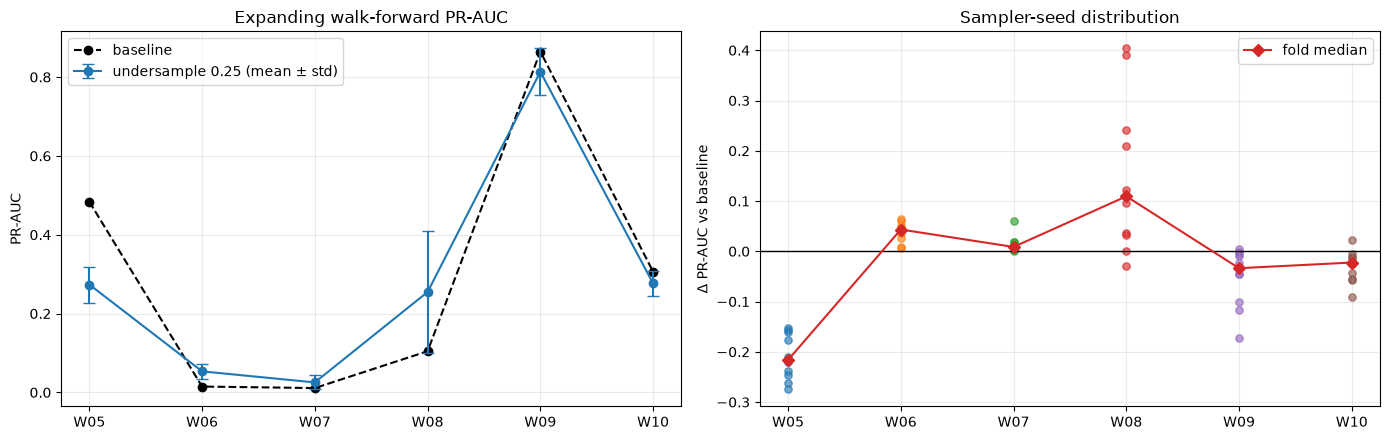

In [8]:
plot_df = walk_forward_fold_summary.reset_index()
positions = np.arange(len(plot_df))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    positions,
    plot_df["baseline_pr_auc"],
    color="black",
    marker="o",
    linestyle="--",
    label="baseline",
)
axes[0].errorbar(
    positions,
    plot_df["undersampled_pr_auc_mean"],
    yerr=plot_df["undersampled_pr_auc_std"].fillna(0),
    marker="o",
    capsize=4,
    label="undersample 0.25 (mean ± std)",
)
axes[0].set_xticks(positions, plot_df["evaluation_window"])
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Expanding walk-forward PR-AUC")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].axhline(0, color="black", linewidth=1)
for position, evaluation_window in enumerate(plot_df["evaluation_window"]):
    values = walk_forward_seed_results.loc[
        walk_forward_seed_results["evaluation_window"] == evaluation_window,
        "delta_pr_auc",
    ]
    axes[1].scatter(
        np.full(len(values), position), values, alpha=0.65, s=28
    )
axes[1].plot(
    positions,
    plot_df["median_delta_pr_auc"],
    color="tab:red",
    marker="D",
    label="fold median",
)
axes[1].set_xticks(positions, plot_df["evaluation_window"])
axes[1].set_ylabel("Δ PR-AUC vs baseline")
axes[1].set_title("Sampler-seed distribution")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 6. 사전 판정 기준

### 1단계 동일 split

- 강한 재현: Validation과 Test 모두 median ΔPR-AUC > 0이고 seed 승률이 각각 80% 이상
- 부분 재현: 두 split 모두 median ΔPR-AUC > 0이고 seed 승률이 각각 60% 이상
- 그 외: 재현 실패

### 2단계 기간 강건성

- 강한 재현: 6개 Fold 중 5개 이상에서 median ΔPR-AUC > 0이고 전체 seed×Fold 승률이 80% 이상
- 부분 재현: 3개 이상 Fold에서 median ΔPR-AUC > 0이고 전체 승률이 60% 이상
- 그 외: 재현 실패

평가 후 기준을 바꾸지 않습니다. 같은 평가 라벨을 10개 seed가 공유하므로 60개 실행을 독립 표본처럼 간주하지 않고, Fold median과 seed 승률을 함께 사용합니다.

In [9]:
if stage1_judgement == "strong" and stage2_judgement == "strong":
    overall_judgement = "strong"
elif stage1_judgement != "failed" and stage2_judgement != "failed":
    overall_judgement = "partial"
else:
    overall_judgement = "not_supported"

stage1_validation = stage1_summary.loc["validation"]
stage1_test = stage1_summary.loc["test"]

result_snapshot = {
    "stage1_judgement": stage1_judgement,
    "stage1_validation_baseline_pr_auc": float(stage1_validation["baseline_pr_auc"]),
    "stage1_validation_under_mean": float(stage1_validation["undersampled_pr_auc_mean"]),
    "stage1_validation_under_std": float(stage1_validation["undersampled_pr_auc_std"]),
    "stage1_validation_win_rate": float(stage1_validation["win_rate_vs_baseline"]),
    "stage1_test_baseline_pr_auc": float(stage1_test["baseline_pr_auc"]),
    "stage1_test_under_mean": float(stage1_test["undersampled_pr_auc_mean"]),
    "stage1_test_under_std": float(stage1_test["undersampled_pr_auc_std"]),
    "stage1_test_win_rate": float(stage1_test["win_rate_vs_baseline"]),
    "stage2_judgement": stage2_judgement,
    "stage2_positive_folds": positive_fold_count,
    "stage2_overall_win_rate": overall_walk_forward_win_rate,
    "stage2_median_delta_pr_auc": overall_median_delta_pr_auc,
    "stage2_q1_delta_pr_auc": overall_q1_delta_pr_auc,
    "overall_judgement": overall_judgement,
}

conclusion = f'''
### 실행 결과 요약

- 1단계 판정: **{stage1_judgement}**
  - Validation: baseline {stage1_validation['baseline_pr_auc']:.6f}, undersampling {stage1_validation['undersampled_pr_auc_mean']:.6f} ± {stage1_validation['undersampled_pr_auc_std']:.6f}, 승률 {stage1_validation['win_rate_vs_baseline']:.0%}
  - Test: baseline {stage1_test['baseline_pr_auc']:.6f}, undersampling {stage1_test['undersampled_pr_auc_mean']:.6f} ± {stage1_test['undersampled_pr_auc_std']:.6f}, 승률 {stage1_test['win_rate_vs_baseline']:.0%}
- 2단계 판정: **{stage2_judgement}**
  - 양의 Fold median: {positive_fold_count}/6
  - 전체 seed×Fold 승률: {overall_walk_forward_win_rate:.0%}
  - 전체 median ΔPR-AUC: {overall_median_delta_pr_auc:.6f}
- 종합 판정: **{overall_judgement}**

1단계는 009 결과의 sampler-seed 재현성을, 2단계는 설정을 고정한 시간축 강건성을 나타냅니다. 절대 PR-AUC는 학습량과 평가 기간이 다른 두 단계 사이에서 직접 비교하지 않습니다. Threshold 0.5 결과는 probability scale 변화가 섞인 보조 결과이며, 운영 threshold 결정은 이 실험의 범위가 아닙니다.

이 실험은 비교 목적이므로 모델 파일을 저장하지 않습니다.
'''
display(Markdown(conclusion))
print("RESULT_SNAPSHOT", result_snapshot)


### 실행 결과 요약

- 1단계 판정: **strong**
  - Validation: baseline 0.050334, undersampling 0.215149 ± 0.110551, 승률 90%
  - Test: baseline 0.356827, undersampling 0.559174 ± 0.037551, 승률 100%
- 2단계 판정: **failed**
  - 양의 Fold median: 3/6
  - 전체 seed×Fold 승률: 52%
  - 전체 median ΔPR-AUC: 0.001135
- 종합 판정: **not_supported**

1단계는 009 결과의 sampler-seed 재현성을, 2단계는 설정을 고정한 시간축 강건성을 나타냅니다. 절대 PR-AUC는 학습량과 평가 기간이 다른 두 단계 사이에서 직접 비교하지 않습니다. Threshold 0.5 결과는 probability scale 변화가 섞인 보조 결과이며, 운영 threshold 결정은 이 실험의 범위가 아닙니다.

이 실험은 비교 목적이므로 모델 파일을 저장하지 않습니다.


RESULT_SNAPSHOT {'stage1_judgement': 'strong', 'stage1_validation_baseline_pr_auc': 0.050334161545785634, 'stage1_validation_under_mean': 0.2151487165600364, 'stage1_validation_under_std': 0.11055092349022203, 'stage1_validation_win_rate': 0.9, 'stage1_test_baseline_pr_auc': 0.3568267324832267, 'stage1_test_under_mean': 0.5591737523770558, 'stage1_test_under_std': 0.03755068879859328, 'stage1_test_win_rate': 1.0, 'stage2_judgement': 'failed', 'stage2_positive_folds': 3, 'stage2_overall_win_rate': 0.5166666666666667, 'stage2_median_delta_pr_auc': 0.0011345527393931054, 'stage2_q1_delta_pr_auc': -0.056259067536170125, 'overall_judgement': 'not_supported'}
